<a href="https://colab.research.google.com/github/KyryloKozlovskyi/garbage-classification/blob/main/garbage_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Waste Image Classification with CNNs

**Module:** Machine Learning Technologies  
**Student ID:** G00425385  
**Seed:** 425385  
**Dataset:** Garbage Classification — 10 categories, 384 × 384 RGB  

---
## 1. Environment Setup

All dependencies are imported upfront so the notebook can be restarted and re-run cleanly.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os, time, timeit, zipfile

from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 425385
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'TensorFlow: {tf.__version__}')
gpu_devices = tf.config.list_physical_devices('GPU')
print(f'GPU detected: {bool(gpu_devices)}  {gpu_devices}')

TensorFlow: 2.20.0
GPU detected: True  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset Preparation

The dataset zip is stored on Google Drive. It is extracted to Colab's local disk for faster I/O during training.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ---- Path configuration ----
ZIP_FILE = '/content/drive/MyDrive/garbage.zip'   # <- update if needed
LOCAL_DIR = '/content/garbage_dataset'

if not os.path.exists(ZIP_FILE):
    print(f'ERROR: {ZIP_FILE} not found.')
    print('Contents of Drive root:')
    for f in sorted(os.listdir('/content/drive/MyDrive'))[:15]:
        print(f'  {f}')
else:
    mb = os.path.getsize(ZIP_FILE) / 1024**2
    print(f'Zip found: {ZIP_FILE} ({mb:.0f} MB)')

Zip found: /content/drive/MyDrive/garbage.zip (390 MB)


In [4]:
# Extract once to local disk
if not os.path.exists(LOCAL_DIR):
    print('Extracting ...')
    with zipfile.ZipFile(ZIP_FILE, 'r') as zf:
        zf.extractall(LOCAL_DIR)
    print('Extraction complete.')
else:
    print('Already extracted.')

Extracting ...
Extraction complete.


In [5]:
# Locate the folder that holds the 10 class sub-directories
TARGET_CLASSES = {
    'battery', 'biological', 'cardboard', 'clothes', 'glass',
    'metal', 'paper', 'plastic', 'shoes', 'trash'
}

DATA_ROOT = None
for dirpath, dirnames, _ in os.walk(LOCAL_DIR):
    if TARGET_CLASSES.issubset(set(dirnames)):
        DATA_ROOT = dirpath
        break

if DATA_ROOT:
    print(f'Dataset root: {DATA_ROOT}')
else:
    print('Could not auto-detect — set DATA_ROOT manually below.')

Dataset root: /content/garbage_dataset/garbage


In [6]:
# Uncomment and set manually only if auto-detection failed
# DATA_ROOT = '/content/garbage_dataset/Garbage_data/Garbage_data'

---
## 3. Exploratory Data Analysis

### 3.1 Class Distribution

Before any modelling, inspecting how many images belong to each category reveals whether class imbalance is present. If one class dominates, accuracy becomes misleading because a model that always predicts the majority class can still score well.

In [7]:
# Count files in each class folder
categories = sorted(
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
)

img_counts = {}
for cat in categories:
    folder = os.path.join(DATA_ROOT, cat)
    n = len([f for f in os.listdir(folder) if not f.startswith('.')])
    img_counts[cat] = n

total = sum(img_counts.values())
largest = max(img_counts, key=img_counts.get)
smallest = min(img_counts, key=img_counts.get)

print(f'{"Category":<14} {"Count":>6}')
print('-' * 22)
for cat, n in sorted(img_counts.items(), key=lambda x: -x[1]):
    print(f'{cat:<14} {n:>6}')
print('-' * 22)
print(f'{"Total":<14} {total:>6}')
print()
print(f'Largest:  {largest} ({img_counts[largest]})')
print(f'Smallest: {smallest} ({img_counts[smallest]})')
print(f'Ratio:    {img_counts[largest] / img_counts[smallest]:.1f}x')

Category        Count
----------------------
clothes          1892
glass            1736
plastic          1597
shoes            1449
cardboard        1411
paper            1336
metal             930
battery           756
biological        699
trash             453
----------------------
Total           12259

Largest:  clothes (1892)
Smallest: trash (453)
Ratio:    4.2x


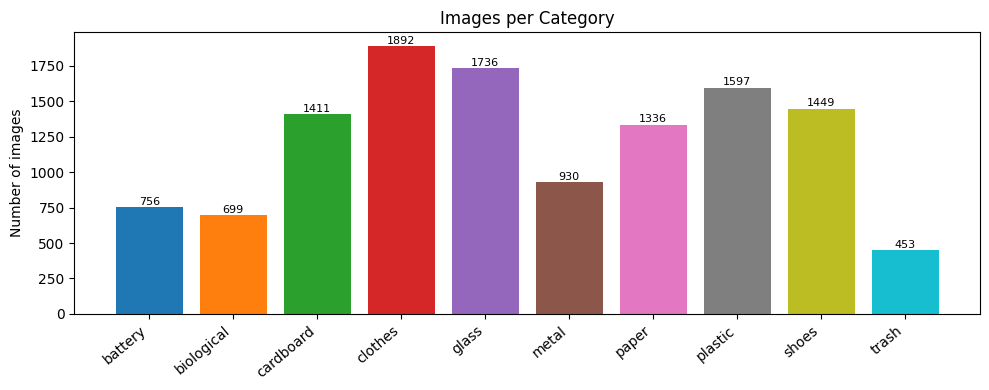

In [8]:
# Visualise the distribution
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(img_counts.keys(), img_counts.values(),
              color=plt.cm.tab10.colors[:len(img_counts)])

for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 15,
            int(b.get_height()), ha='center', fontsize=8)

ax.set_ylabel('Number of images')
ax.set_title('Images per Category')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

### 3.2 Sample Images

Viewing a few images from every class gives an intuition for how varied the data is and which categories might be visually similar.

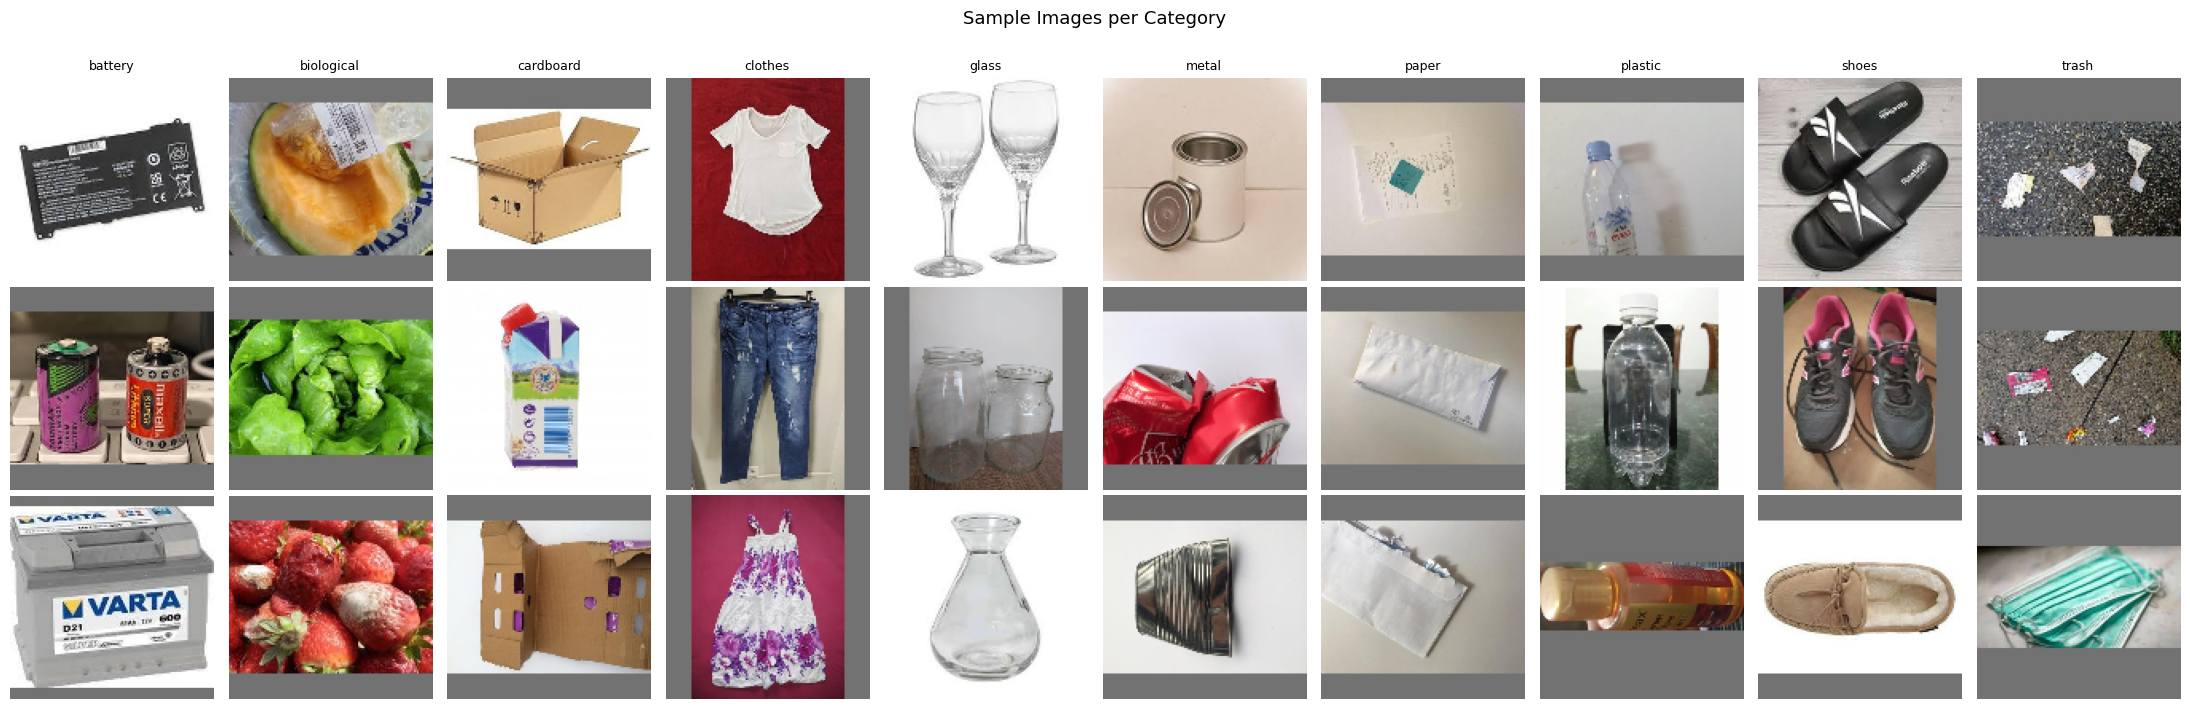

In [9]:
n_show = 3  # images per class
fig, axes = plt.subplots(n_show, len(categories), figsize=(22, 7))

for col_idx, cat in enumerate(categories):
    folder = os.path.join(DATA_ROOT, cat)
    samples = sorted(os.listdir(folder))[:n_show]
    for row_idx, fname in enumerate(samples):
        img = tf.keras.utils.load_img(
            os.path.join(folder, fname), target_size=(128, 128)
        )
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
    axes[0, col_idx].set_title(cat, fontsize=9)

fig.suptitle('Sample Images per Category', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Image Dimensions and Pixel Values

Confirming that images have consistent dimensions and checking the raw pixel range.

In [10]:
# Sample a few images per class to check dimensions
shapes_seen = set()
px_lo, px_hi = 255, 0

for cat in categories:
    folder = os.path.join(DATA_ROOT, cat)
    for fname in sorted(os.listdir(folder))[:5]:
        arr = np.array(
            tf.keras.utils.load_img(os.path.join(folder, fname))
        )
        shapes_seen.add(arr.shape)
        px_lo = min(px_lo, arr.min())
        px_hi = max(px_hi, arr.max())

print(f'Unique shapes found: {shapes_seen}')
print(f'Pixel range: [{px_lo}, {px_hi}]')

Unique shapes found: {(384, 384, 3)}
Pixel range: [0, 255]


---
## 4. Data Loading and Splitting

The data is loaded with `image_dataset_from_directory` and split 70 / 10 / 20 (train / validation / test). Keras only supports a single split parameter, so a 70/30 split is performed first, then the 30 % holdout is divided into one-third validation and two-thirds test.

The **validation** set is used throughout to compare models and select hyperparameters. The **test** set is reserved for a single final evaluation of the chosen model.

In [11]:
# ---- Hyperparameters ----
IMG_H = 128
IMG_W = 128
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

In [12]:
# 70 % training
ds_train = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.3,
    subset='training',
    seed=SEED,
    image_size=(IMG_H, IMG_W),
    batch_size=BATCH,
    label_mode='int'
)

# 30 % holdout
ds_holdout = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.3,
    subset='validation',
    seed=SEED,
    image_size=(IMG_H, IMG_W),
    batch_size=BATCH,
    label_mode='int'
)

# Split holdout: first third → validation, remainder → test
holdout_size = tf.data.experimental.cardinality(ds_holdout).numpy()
n_val = holdout_size // 3

ds_val = ds_holdout.take(n_val)
ds_test = ds_holdout.skip(n_val)

label_names = ds_train.class_names
n_classes = len(label_names)

print(f'Labels ({n_classes}): {label_names}')
print(f'Batches  — train: {tf.data.experimental.cardinality(ds_train).numpy()}, '
      f'val: {tf.data.experimental.cardinality(ds_val).numpy()}, '
      f'test: {tf.data.experimental.cardinality(ds_test).numpy()}')

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.
Labels (10): ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Batches  — train: 269, val: 38, test: 77


In [13]:
# Verify split sizes
n_train = sum(labels.shape[0] for _, labels in ds_train)
n_val_img = sum(labels.shape[0] for _, labels in ds_val)
n_test = sum(labels.shape[0] for _, labels in ds_test)

print(f'Images   — train: {n_train}, val: {n_val_img}, test: {n_test}')
print(f'Total: {n_train + n_val_img + n_test}')

Images   — train: 8582, val: 1216, test: 2461
Total: 12259


In [14]:
# Quick sanity check: shape and range of one batch
for batch_imgs, batch_labels in ds_train.take(1):
    print(f'Image batch: {batch_imgs.shape}  dtype={batch_imgs.dtype}')
    print(f'Label batch: {batch_labels.shape}  dtype={batch_labels.dtype}')
    print(f'Pixel range: [{batch_imgs.numpy().min():.0f}, {batch_imgs.numpy().max():.0f}]')

Image batch: (32, 128, 128, 3)  dtype=<dtype: 'float32'>
Label batch: (32,)  dtype=<dtype: 'int32'>
Pixel range: [0, 255]


### 4.1 Class Weights

Because the dataset is imbalanced, class weights are computed so that misclassifying a rare category (e.g. trash) costs more than misclassifying a common one (e.g. clothes). These weights are passed to `model.fit()` through the `class_weight` parameter.

In [15]:
# Gather all training labels
all_train_labels = np.concatenate(
    [labels.numpy() for _, labels in ds_train]
)

cw = compute_class_weight(
    'balanced',
    classes=np.arange(n_classes),
    y=all_train_labels
)
class_weights = {i: w for i, w in enumerate(cw)}

print(f'{"Class":<14} {"Weight":>8}')
print('-' * 24)
for i, name in enumerate(label_names):
    print(f'{name:<14} {class_weights[i]:>8.4f}')

Class            Weight
------------------------
battery          1.5718
biological       1.7130
cardboard        0.8642
clothes          0.6571
glass            0.6910
metal            1.3451
paper            0.9525
plastic          0.7711
shoes            0.8284
trash            2.8046


### 4.2 Performance Optimisation

Prefetching allows the data pipeline to prepare the next batch while the GPU is training on the current one.

In [16]:
ds_train = ds_train.cache().prefetch(AUTOTUNE)
ds_val   = ds_val.cache().prefetch(AUTOTUNE)
ds_test  = ds_test.cache().prefetch(AUTOTUNE)

---
## 5. Utility Functions

Reusable helpers for plotting training curves, computing metrics, and displaying confusion matrices.

In [17]:
def show_curves(hist, title=''):
    """Side-by-side accuracy and loss plots from a Keras History object."""
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    if title:
        fig.suptitle(title, fontsize=13)

    a1.plot(hist.history['accuracy'],     label='train')
    a1.plot(hist.history['val_accuracy'],  label='val')
    a1.set_xlabel('Epoch'); a1.set_ylabel('Accuracy')
    a1.legend(); a1.grid(True, alpha=0.3)

    a2.plot(hist.history['loss'],     label='train')
    a2.plot(hist.history['val_loss'],  label='val')
    a2.set_xlabel('Epoch'); a2.set_ylabel('Loss')
    a2.legend(); a2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def get_predictions(model, dataset):
    """Return ground-truth and predicted label arrays for a dataset."""
    y_true, y_pred = [], []
    for imgs, lbls in dataset:
        logits = model.predict(imgs, verbose=0)
        y_true.append(lbls.numpy())
        y_pred.append(np.argmax(logits, axis=1))
    return np.concatenate(y_true), np.concatenate(y_pred)


def report_metrics(model, dataset, tag='Validation'):
    """Print accuracy, macro-F1, per-class report, and return predictions."""
    y_true, y_pred = get_predictions(model, dataset)

    acc  = np.mean(y_true == y_pred)
    mf1  = f1_score(y_true, y_pred, average='macro')

    print(f'\n=== {tag} ===')
    print(f'Accuracy :  {acc:.4f}')
    print(f'Macro F1 :  {mf1:.4f}')
    print(f'Parameters: {model.count_params():,}')
    print()
    print(classification_report(y_true, y_pred,
                                target_names=label_names))
    return y_true, y_pred, mf1


def show_confusion(y_true, y_pred, title=''):
    """Display a labelled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(ax=ax, cmap='Oranges', xticks_rotation=45)
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()


def measure_inference(model, dataset, n_runs=10):
    """Average inference time over n_runs using timeit on one batch."""
    one_batch = next(iter(dataset))[0]
    t = timeit.timeit(
        lambda: model.predict(one_batch, verbose=0),
        number=n_runs
    ) / n_runs
    print(f'Mean inference time (1 batch, {n_runs} runs): {t:.4f} s')
    return t

---
## 6. Data Augmentation

Data augmentation creates slightly different versions of each training image on every epoch (flipping, rotating, etc.). This helps the model learn general features rather than memorising specific training images, which reduces overfitting.

The augmentation layer is placed inside the model so it only runs during training and is automatically disabled at inference time.

In [18]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.2),
])

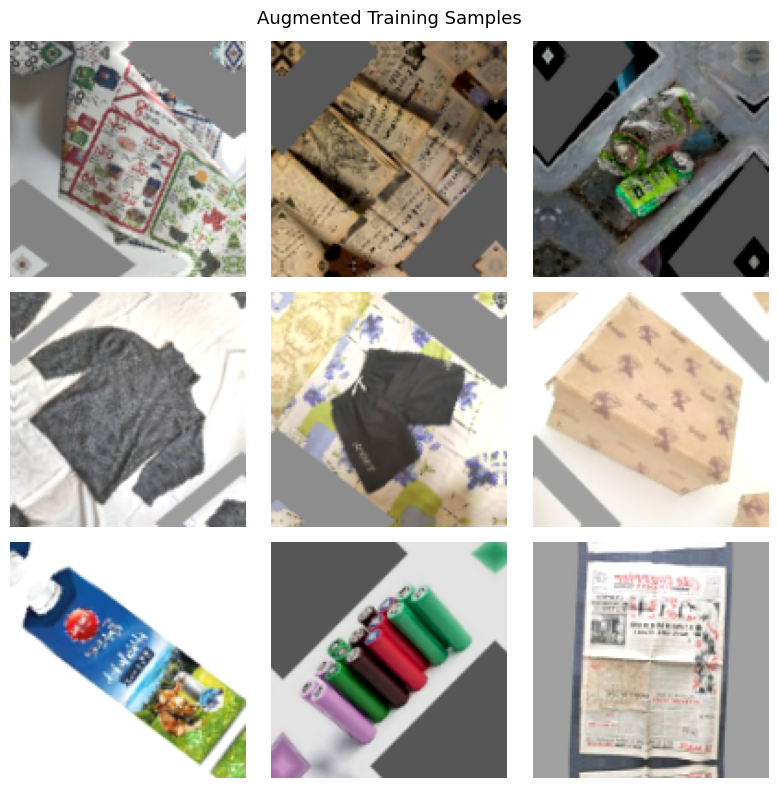

In [19]:
# Preview augmented images
sample_batch = next(iter(ds_train))[0][:9]  # grab 9 images

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    augmented = augmentation(tf.expand_dims(sample_batch[i], 0))
    ax.imshow(augmented[0].numpy().astype('uint8'))
    ax.axis('off')
fig.suptitle('Augmented Training Samples', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. CNN from Scratch (RGB, 128x128)

### 7.1 Baseline Model

The first model follows the same pattern used in the beans classification lab: three convolutional blocks with increasing filter counts (16, 32, 64), each followed by max pooling. A `Rescaling` layer normalises pixel values from [0, 255] to [0, 1].

The output layer has no activation function; instead, `from_logits=True` is set in the loss function, which is numerically more stable than applying softmax separately.

In [20]:
# Baseline RGB CNN
rgb_baseline = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 3)),
    augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Classifier head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(n_classes)  # no activation, using from_logits=True
])

rgb_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

rgb_baseline.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,194 (129.66 KB)

 Trainable params: 33,194 (129.66 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Train the baseline
EPOCHS = 30

t0 = time.time()
hist_baseline = rgb_baseline.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    class_weight=class_weights,
)
baseline_time = time.time() - t0
print(f'\nTraining time: {baseline_time:.1f}s ({baseline_time/60:.1f} min)')

Epoch 1/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.1348 - loss: 2.1937 - val_accuracy: 0.1875 - val_loss: 2.1304
Epoch 2/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.2121 - loss: 2.0486 - val_accuracy: 0.2640 - val_loss: 2.0059
Epoch 3/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2908 - loss: 1.9117 - val_accuracy: 0.2837 - val_loss: 1.9656
Epoch 4/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3274 - loss: 1.8369 - val_accuracy: 0.3215 - val_loss: 1.8694
Epoch 5/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3468 - loss: 1.7881 - val_accuracy: 0.3438 - val_loss: 1.7979
Epoch 6/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3707 - loss: 1.7485 - val_accuracy: 0.3586 - val_loss: 1.7620
Epoch 7/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3860 - loss: 1.7075 - val_accuracy: 0.3553 - val_loss: 1.7913
Epoch 8/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4032 - loss: 1.6784 - val_acc

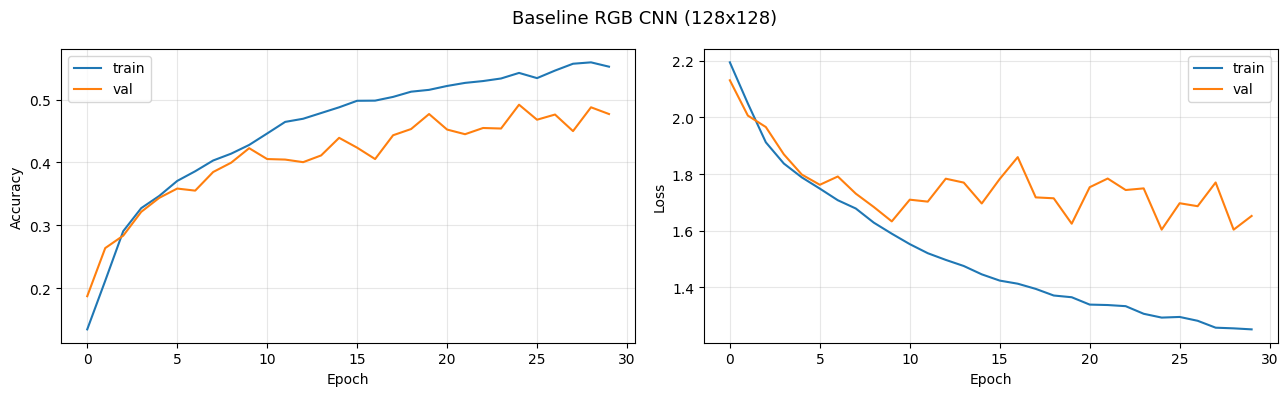

In [22]:
show_curves(hist_baseline, 'Baseline RGB CNN (128x128)')

In [23]:
y_true_b, y_pred_b, f1_baseline = report_metrics(
    rgb_baseline, ds_val, tag='Baseline RGB (128) - Validation'
)


=== Baseline RGB (128) - Validation ===
Accuracy :  0.4770
Macro F1 :  0.4481
Parameters: 33,194

              precision    recall  f1-score   support

     battery       0.43      0.81      0.56        68
  biological       0.53      0.68      0.60        78
   cardboard       0.46      0.78      0.58       139
     clothes       0.68      0.61      0.64       198
       glass       0.71      0.18      0.29       163
       metal       0.35      0.24      0.29        95
       paper       0.34      0.61      0.44       135
     plastic       0.63      0.37      0.47       169
       shoes       0.46      0.21      0.29       126
       trash       0.26      0.42      0.32        45

    accuracy                           0.48      1216
   macro avg       0.49      0.49      0.45      1216
weighted avg       0.53      0.48      0.46      1216



### 7.2 Diagnosis and Iteration

Looking at the training curves above, the gap between training and validation tells us whether the model is overfitting or underfitting.

If the training accuracy keeps climbing while validation accuracy levels off, that means the model is memorising the training data. To address this, the next model adds dropout after each pooling layer and uses early stopping to halt training when validation loss stops improving.

In [24]:
# Improved RGB CNN with dropout and early stopping
rgb_v2 = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 3)),
    augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Block 3
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Classifier head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(n_classes)
])

rgb_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

rgb_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,194 (129.66 KB)

 Trainable params: 33,194 (129.66 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Early stopping callback
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

t0 = time.time()
hist_v2 = rgb_v2.fit(
    ds_train,
    validation_data=ds_val,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stop],
)
v2_time = time.time() - t0
print(f'\nTraining time: {v2_time:.1f}s ({v2_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.1262 - loss: 2.2252 - val_accuracy: 0.1727 - val_loss: 2.1741
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.1656 - loss: 2.1219 - val_accuracy: 0.2015 - val_loss: 2.1770
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.2041 - loss: 2.0554 - val_accuracy: 0.2262 - val_loss: 2.1759
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2453 - loss: 1.9901 - val_accuracy: 0.2804 - val_loss: 2.0520
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2755 - loss: 1.9465 - val_accuracy: 0.2755 - val_loss: 2.1371
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2947 - loss: 1.9100 - val_accuracy: 0.2747 - val_loss: 2.0838
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.2976 - loss: 1.8957 - val_accuracy: 0.2771 - val_loss: 2.0867
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3113 - loss: 1.8673 - val_accu

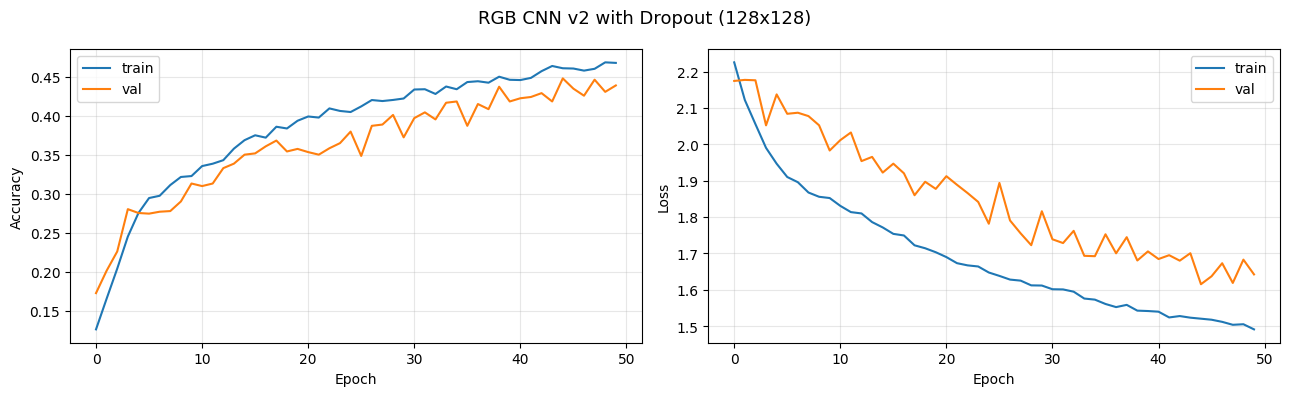

In [26]:
show_curves(hist_v2, 'RGB CNN v2 with Dropout (128x128)')

In [27]:
y_true_v2, y_pred_v2, f1_v2 = report_metrics(
    rgb_v2, ds_val, tag='RGB v2 with Dropout (128) - Validation'
)


=== RGB v2 with Dropout (128) - Validation ===
Accuracy :  0.4482
Macro F1 :  0.4155
Parameters: 33,194

              precision    recall  f1-score   support

     battery       0.39      0.85      0.54        68
  biological       0.50      0.76      0.60        78
   cardboard       0.51      0.71      0.59       139
     clothes       0.64      0.59      0.61       198
       glass       0.64      0.15      0.25       163
       metal       0.20      0.19      0.19        95
       paper       0.36      0.60      0.45       135
     plastic       0.64      0.29      0.40       169
       shoes       0.31      0.22      0.26       126
       trash       0.25      0.29      0.27        45

    accuracy                           0.45      1216
   macro avg       0.44      0.46      0.42      1216
weighted avg       0.49      0.45      0.43      1216



### 7.3 Deeper Network

The project spec asks whether adding more convolutional layers helps. This version adds a fourth block with 128 filters to see if extra depth can pick up finer details in the images.

In [28]:
# Deeper CNN with 4 convolutional blocks
rgb_deep = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 3)),
    augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(n_classes)
])

rgb_deep.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f'Parameters: {rgb_deep.count_params():,}')

Parameters: 115,242


In [29]:
t0 = time.time()
hist_deep = rgb_deep.fit(
    ds_train,
    validation_data=ds_val,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
deep_time = time.time() - t0
print(f'\nTraining time: {deep_time:.1f}s ({deep_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.1193 - loss: 2.2411 - val_accuracy: 0.1316 - val_loss: 2.1916
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.1627 - loss: 2.1354 - val_accuracy: 0.2286 - val_loss: 2.1194
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2351 - loss: 2.0227 - val_accuracy: 0.2648 - val_loss: 2.0402
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.2696 - loss: 1.9670 - val_accuracy: 0.2903 - val_loss: 2.0257
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.3035 - loss: 1.9069 - val_accuracy: 0.3150 - val_loss: 1.9467
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3250 - loss: 1.8574 - val_accuracy: 0.3438 - val_loss: 1.8859
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.3476 - loss: 1.8231 - val_accuracy: 0.3438 - val_loss: 1.8517
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3570 - loss: 1.7866 - val_accu

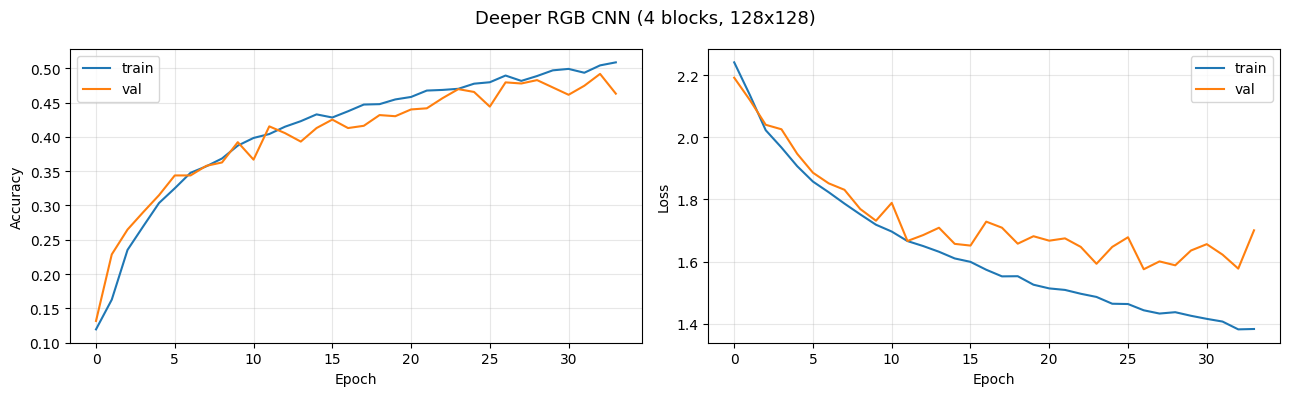

In [30]:
show_curves(hist_deep, 'Deeper RGB CNN (4 blocks, 128x128)')

In [31]:
y_true_d, y_pred_d, f1_deep = report_metrics(
    rgb_deep, ds_val, tag='Deeper RGB CNN (128) - Validation'
)


=== Deeper RGB CNN (128) - Validation ===
Accuracy :  0.4794
Macro F1 :  0.4531
Parameters: 115,242

              precision    recall  f1-score   support

     battery       0.48      0.79      0.60        68
  biological       0.54      0.64      0.58        78
   cardboard       0.55      0.73      0.63       139
     clothes       0.62      0.66      0.64       198
       glass       0.80      0.22      0.35       163
       metal       0.30      0.48      0.37        95
       paper       0.40      0.52      0.45       135
     plastic       0.57      0.35      0.43       169
       shoes       0.31      0.16      0.21       126
       trash       0.22      0.36      0.27        45

    accuracy                           0.48      1216
   macro avg       0.48      0.49      0.45      1216
weighted avg       0.52      0.48      0.46      1216



### 7.4 Smaller Image Size (64x64)

The spec asks to compare at least two image sizes. Training on 64x64 images is much faster and uses less memory. The trade-off is that shrinking the image throws away fine detail, which could hurt accuracy for categories that rely on texture differences (like paper vs cardboard).

In [32]:
# Load data at 64x64
IMG_SMALL = 64

ds_train_64 = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT, validation_split=0.3, subset='training',
    seed=SEED, image_size=(IMG_SMALL, IMG_SMALL),
    batch_size=BATCH, label_mode='int'
)
ds_holdout_64 = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT, validation_split=0.3, subset='validation',
    seed=SEED, image_size=(IMG_SMALL, IMG_SMALL),
    batch_size=BATCH, label_mode='int'
)

h64 = tf.data.experimental.cardinality(ds_holdout_64).numpy()
ds_val_64  = ds_holdout_64.take(h64 // 3).cache().prefetch(AUTOTUNE)
ds_test_64 = ds_holdout_64.skip(h64 // 3).cache().prefetch(AUTOTUNE)
ds_train_64 = ds_train_64.cache().prefetch(AUTOTUNE)

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [33]:
# Same architecture as v2 but input is 64x64
augmentation_64 = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.2),
])

rgb_small = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_SMALL, IMG_SMALL, 3)),
    augmentation_64,
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(n_classes)
])

rgb_small.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f'Parameters: {rgb_small.count_params():,}')

Parameters: 33,194


In [34]:
t0 = time.time()
hist_small = rgb_small.fit(
    ds_train_64,
    validation_data=ds_val_64,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
small_time = time.time() - t0
print(f'\nTraining time: {small_time:.1f}s ({small_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.1178 - loss: 2.2407 - val_accuracy: 0.1505 - val_loss: 2.1855
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.1619 - loss: 2.1604 - val_accuracy: 0.2623 - val_loss: 2.0957
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2255 - loss: 2.0932 - val_accuracy: 0.3174 - val_loss: 2.0071
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2632 - loss: 2.0338 - val_accuracy: 0.3347 - val_loss: 1.9595
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2934 - loss: 1.9615 - val_accuracy: 0.3183 - val_loss: 1.9705
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3070 - loss: 1.9020 - val_accuracy: 0.2936 - val_loss: 2.0963
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3231 - loss: 1.8760 - val_accuracy: 0.3248 - val_loss: 1.9766
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3317 - loss: 1.8456 - val_accura

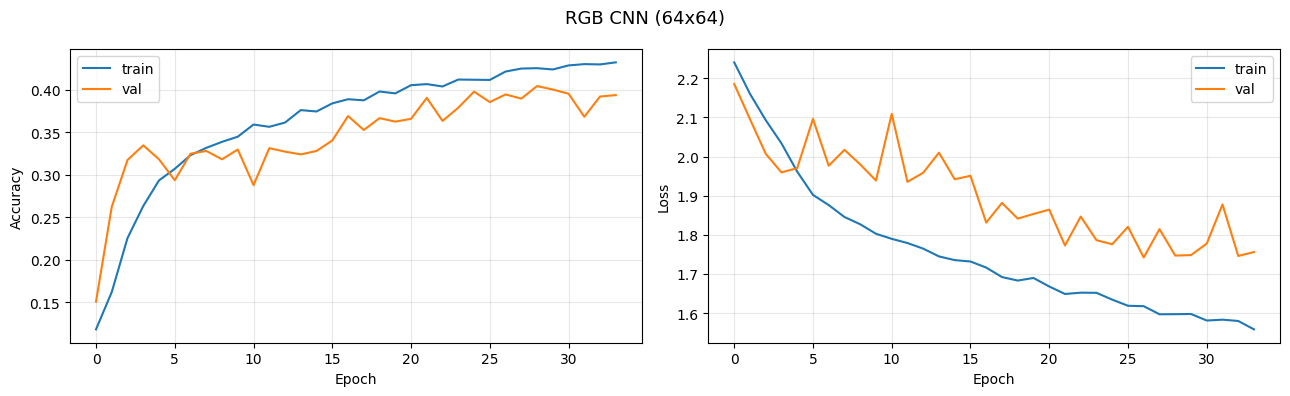

In [35]:
show_curves(hist_small, 'RGB CNN (64x64)')

In [36]:
y_true_s, y_pred_s, f1_small = report_metrics(
    rgb_small, ds_val_64, tag='RGB CNN (64x64) - Validation'
)


=== RGB CNN (64x64) - Validation ===
Accuracy :  0.3947
Macro F1 :  0.3621
Parameters: 33,194

              precision    recall  f1-score   support

     battery       0.29      0.90      0.44        67
  biological       0.33      0.86      0.48        76
   cardboard       0.44      0.50      0.47       139
     clothes       0.70      0.50      0.58       204
       glass       0.69      0.13      0.22       170
       metal       0.15      0.11      0.13        87
       paper       0.32      0.48      0.38       130
     plastic       0.62      0.29      0.40       171
       shoes       0.31      0.23      0.26       129
       trash       0.28      0.26      0.27        43

    accuracy                           0.39      1216
   macro avg       0.41      0.42      0.36      1216
weighted avg       0.47      0.39      0.38      1216



### 7.5 RGB Model Comparison

Comparing all RGB scratch models side by side on the validation set. The primary metric is macro F1, as it accounts for class imbalance.

In [37]:
# Summary table
scratch_results = {
    'Model':     ['Baseline (128)', 'v2 Dropout (128)', 'Deeper (128)', 'Small (64)'],
    'Macro F1':  [f1_baseline, f1_v2, f1_deep, f1_small],
    'Params':    [rgb_baseline.count_params(), rgb_v2.count_params(),
                  rgb_deep.count_params(), rgb_small.count_params()],
    'Time (s)':  [baseline_time, v2_time, deep_time, small_time],
}

print(f'{"Model":<22} {"Macro F1":>10} {"Params":>12} {"Time (s)":>10}')
print('-' * 58)
for i in range(len(scratch_results['Model'])):
    print(f'{scratch_results["Model"][i]:<22} '
          f'{scratch_results["Macro F1"][i]:>10.4f} '
          f'{scratch_results["Params"][i]:>12,} '
          f'{scratch_results["Time (s)"][i]:>10.1f}')

Model                    Macro F1       Params   Time (s)
----------------------------------------------------------
Baseline (128)             0.4481       33,194      126.3
v2 Dropout (128)           0.4155       33,194      230.6
Deeper (128)               0.4531      115,242      169.7
Small (64)                 0.3621       33,194      112.9


Based on the validation macro F1 scores above, select the best performing RGB CNN. This model's hyperparameters will be reused for the greyscale comparison in the next section.

---
## 8. CNN from Scratch (Greyscale)

The spec requires a direct comparison of RGB vs greyscale using the same hyperparameters. Colour usually carries useful information for object recognition, but some waste categories might be identifiable from shape alone. This test reveals whether the model actually relies on colour cues or not.

In [38]:
# Load greyscale version of the data at 128x128
ds_train_grey = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT, validation_split=0.3, subset='training',
    seed=SEED, image_size=(IMG_H, IMG_W),
    batch_size=BATCH, label_mode='int',
    color_mode='grayscale'
)
ds_holdout_grey = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT, validation_split=0.3, subset='validation',
    seed=SEED, image_size=(IMG_H, IMG_W),
    batch_size=BATCH, label_mode='int',
    color_mode='grayscale'
)

hg = tf.data.experimental.cardinality(ds_holdout_grey).numpy()
ds_val_grey  = ds_holdout_grey.take(hg // 3).cache().prefetch(AUTOTUNE)
ds_test_grey = ds_holdout_grey.skip(hg // 3).cache().prefetch(AUTOTUNE)
ds_train_grey = ds_train_grey.cache().prefetch(AUTOTUNE)

# Confirm shape
for imgs, _ in ds_train_grey.take(1):
    print(f'Greyscale batch shape: {imgs.shape}')

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.
Greyscale batch shape: (32, 128, 128, 1)


In [39]:
# Same architecture as v2 but with 1 input channel instead of 3
augmentation_grey = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

grey_model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 1)),
    augmentation_grey,
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(n_classes)
])

grey_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f'Greyscale params: {grey_model.count_params():,}')

Greyscale params: 32,906


In [40]:
t0 = time.time()
hist_grey = grey_model.fit(
    ds_train_grey,
    validation_data=ds_val_grey,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
grey_time = time.time() - t0
print(f'\nTraining time: {grey_time:.1f}s ({grey_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.0794 - loss: 2.2985 - val_accuracy: 0.1242 - val_loss: 2.2948
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.1533 - loss: 2.2300 - val_accuracy: 0.2294 - val_loss: 2.1773
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2212 - loss: 2.1150 - val_accuracy: 0.2253 - val_loss: 2.1699
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2299 - loss: 2.0598 - val_accuracy: 0.2451 - val_loss: 2.0817
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2396 - loss: 2.0411 - val_accuracy: 0.2508 - val_loss: 2.0651
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2416 - loss: 2.0225 - val_accuracy: 0.2582 - val_loss: 2.0550
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2455 - loss: 2.0073 - val_accuracy: 0.2615 - val_loss: 2.0540
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2558 - loss: 1.9962 - val_acc

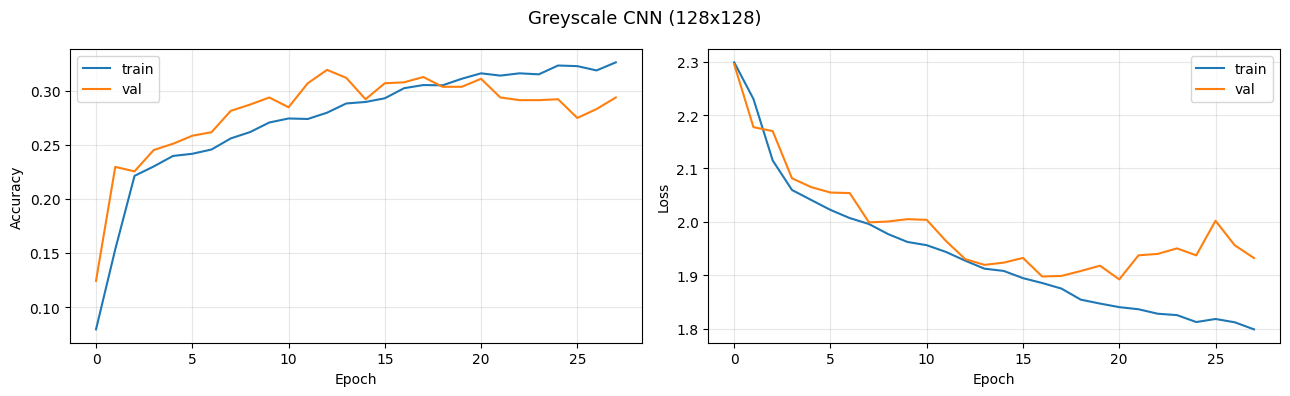

In [41]:
show_curves(hist_grey, 'Greyscale CNN (128x128)')

In [42]:
y_true_g, y_pred_g, f1_grey = report_metrics(
    grey_model, ds_val_grey, tag='Greyscale CNN (128) - Validation'
)


=== Greyscale CNN (128) - Validation ===
Accuracy :  0.3109
Macro F1 :  0.2712
Parameters: 32,906

              precision    recall  f1-score   support

     battery       0.54      0.64      0.59        67
  biological       0.39      0.18      0.25        76
   cardboard       0.50      0.11      0.18       139
     clothes       0.38      0.69      0.49       204
       glass       0.48      0.06      0.11       170
       metal       0.16      0.44      0.23        87
       paper       0.29      0.47      0.36       130
     plastic       0.44      0.21      0.28       171
       shoes       0.25      0.02      0.03       129
       trash       0.12      0.40      0.19        43

    accuracy                           0.31      1216
   macro avg       0.35      0.32      0.27      1216
weighted avg       0.38      0.31      0.27      1216



### 8.1 RGB vs Greyscale

Directly comparing the RGB and greyscale models that used the same hyperparameters.

In [43]:
print(f'{"":<16} {"Macro F1":>10} {"Params":>12}')
print('-' * 40)
print(f'{"RGB (v2)":<16} {f1_v2:>10.4f} {rgb_v2.count_params():>12,}')
print(f'{"Greyscale":<16} {f1_grey:>10.4f} {grey_model.count_params():>12,}')
print()
diff = f1_v2 - f1_grey
if diff > 0:
    print(f'RGB outperforms greyscale by {diff:.4f} macro F1.')
else:
    print(f'Greyscale outperforms RGB by {-diff:.4f} macro F1.')

                   Macro F1       Params
----------------------------------------
RGB (v2)             0.4155       33,194
Greyscale            0.2712       32,906

RGB outperforms greyscale by 0.1443 macro F1.


---
## 9. Addressing Underfitting

### 9.1 Diagnosis

The training curves from Section 7 show a consistent pattern across all models: training accuracy plateaus around 50-55% and the gap between training and validation accuracy is small. This is a textbook sign of **underfitting**. The model does not have enough capacity to capture the differences between 10 waste categories.

Adding dropout to v2 made the problem worse (F1 dropped from 0.47 to 0.32), which confirms the diagnosis. Dropout regularises an overfitting model, but applying it to an underfitting model just makes learning harder.

The lab's architecture (16, 32, 64 filters) was designed for a 3-class problem (beans). Ten classes with more visual variety need more filters so the network can learn a wider range of features.

### 9.2 Increased Capacity Model

This version doubles the filter counts to 32, 64, 128 and uses only light dropout (0.15) in the convolutional blocks. The classifier head is also wider at 256 units. The goal is to give the network enough room to learn without over-regularising.

In [44]:
# v3: more capacity to fix underfitting
rgb_v3 = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 3)),
    augmentation,
    layers.Rescaling(1./255),

    # Block 1 - 32 filters
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.15),

    # Block 2 - 64 filters
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.15),

    # Block 3 - 128 filters
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Wider classifier head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes)
])

rgb_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

rgb_v3.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,842 (503.29 KB)

 Trainable params: 128,842 (503.29 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
t0 = time.time()
hist_v3 = rgb_v3.fit(
    ds_train,
    validation_data=ds_val,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
v3_time = time.time() - t0
print(f'\nTraining time: {v3_time:.1f}s ({v3_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.1274 - loss: 2.2079 - val_accuracy: 0.1891 - val_loss: 2.1313
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.2285 - loss: 2.0576 - val_accuracy: 0.2738 - val_loss: 2.0239
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.2959 - loss: 1.9474 - val_accuracy: 0.2961 - val_loss: 1.9777
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.3247 - loss: 1.8693 - val_accuracy: 0.2796 - val_loss: 2.0748
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.3436 - loss: 1.8144 - val_accuracy: 0.3100 - val_loss: 2.0598
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.3559 - loss: 1.7748 - val_accuracy: 0.3372 - val_loss: 1.9170
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.3794 - loss: 1.7368 - val_accuracy: 0.3627 - val_loss: 1.8203
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.3888 - loss: 1.7026 - val_ac

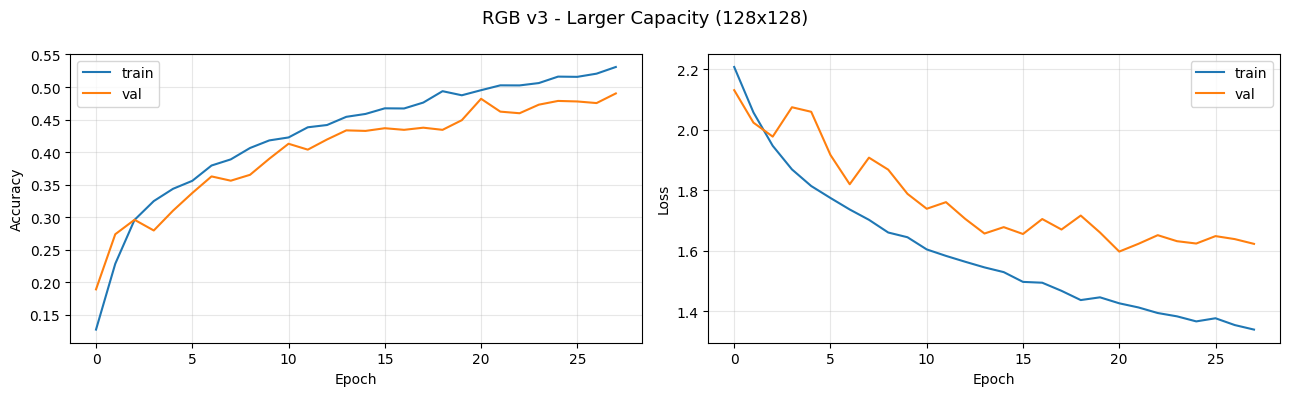

In [46]:
show_curves(hist_v3, 'RGB v3 - Larger Capacity (128x128)')

In [47]:
y_true_v3, y_pred_v3, f1_v3 = report_metrics(
    rgb_v3, ds_val, tag='RGB v3 Larger Capacity (128) - Validation'
)


=== RGB v3 Larger Capacity (128) - Validation ===
Accuracy :  0.4819
Macro F1 :  0.4513
Parameters: 128,842

              precision    recall  f1-score   support

     battery       0.41      0.85      0.55        68
  biological       0.52      0.72      0.61        78
   cardboard       0.63      0.68      0.66       139
     clothes       0.60      0.66      0.63       198
       glass       0.80      0.23      0.35       163
       metal       0.27      0.37      0.31        95
       paper       0.41      0.62      0.49       135
     plastic       0.62      0.33      0.43       169
       shoes       0.33      0.15      0.21       126
       trash       0.23      0.36      0.28        45

    accuracy                           0.48      1216
   macro avg       0.48      0.50      0.45      1216
weighted avg       0.53      0.48      0.46      1216



### 9.3 Updated Scratch Model Comparison

In [48]:
all_scratch = {
    'Model':    ['Baseline (128)', 'v2 Dropout (128)', 'Deeper (128)',
                 'Small (64)', 'v3 Larger (128)'],
    'Macro F1': [f1_baseline, f1_v2, f1_deep, f1_small, f1_v3],
    'Params':   [rgb_baseline.count_params(), rgb_v2.count_params(),
                 rgb_deep.count_params(), rgb_small.count_params(),
                 rgb_v3.count_params()],
    'Time (s)': [baseline_time, v2_time, deep_time, small_time, v3_time],
}

print(f'{"Model":<22} {"Macro F1":>10} {"Params":>12} {"Time (s)":>10}')
print('-' * 58)
for i in range(len(all_scratch['Model'])):
    marker = ' <-- best' if all_scratch['Macro F1'][i] == max(all_scratch['Macro F1']) else ''
    print(f'{all_scratch["Model"][i]:<22} '
          f'{all_scratch["Macro F1"][i]:>10.4f} '
          f'{all_scratch["Params"][i]:>12,} '
          f'{all_scratch["Time (s)"][i]:>10.1f}{marker}')

Model                    Macro F1       Params   Time (s)
----------------------------------------------------------
Baseline (128)             0.4481       33,194      126.3
v2 Dropout (128)           0.4155       33,194      230.6
Deeper (128)               0.4531      115,242      169.7 <-- best
Small (64)                 0.3621       33,194      112.9
v3 Larger (128)            0.4513      128,842      215.8


### 9.4 Greyscale with Larger Capacity

The greyscale comparison from Section 8 used the smaller v2 architecture, which was underfitting. For a fair comparison, the greyscale model should use the same architecture as the best RGB model (v3). This way the only difference is the colour information.

In [49]:
# Greyscale v3 - same filters as RGB v3 but 1 channel input
augmentation_grey_v3 = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

grey_v3 = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 1)),
    augmentation_grey_v3,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.15),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.15),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes)
])

grey_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f'Greyscale v3 params: {grey_v3.count_params():,}')

Greyscale v3 params: 128,266


In [50]:
t0 = time.time()
hist_grey_v3 = grey_v3.fit(
    ds_train_grey,
    validation_data=ds_val_grey,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
grey_v3_time = time.time() - t0
print(f'\nTraining time: {grey_v3_time:.1f}s ({grey_v3_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.1220 - loss: 2.2678 - val_accuracy: 0.2081 - val_loss: 2.1979
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.2200 - loss: 2.1124 - val_accuracy: 0.1998 - val_loss: 2.2307
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.2389 - loss: 2.0290 - val_accuracy: 0.2196 - val_loss: 2.1712
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.2580 - loss: 1.9988 - val_accuracy: 0.2467 - val_loss: 2.1180
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.2679 - loss: 1.9732 - val_accuracy: 0.2788 - val_loss: 2.0439
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.2765 - loss: 1.9553 - val_accuracy: 0.2623 - val_loss: 2.0343
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.2883 - loss: 1.9333 - val_accuracy: 0.2821 - val_loss: 2.0189
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.2899 - loss: 1.9111 - val_acc

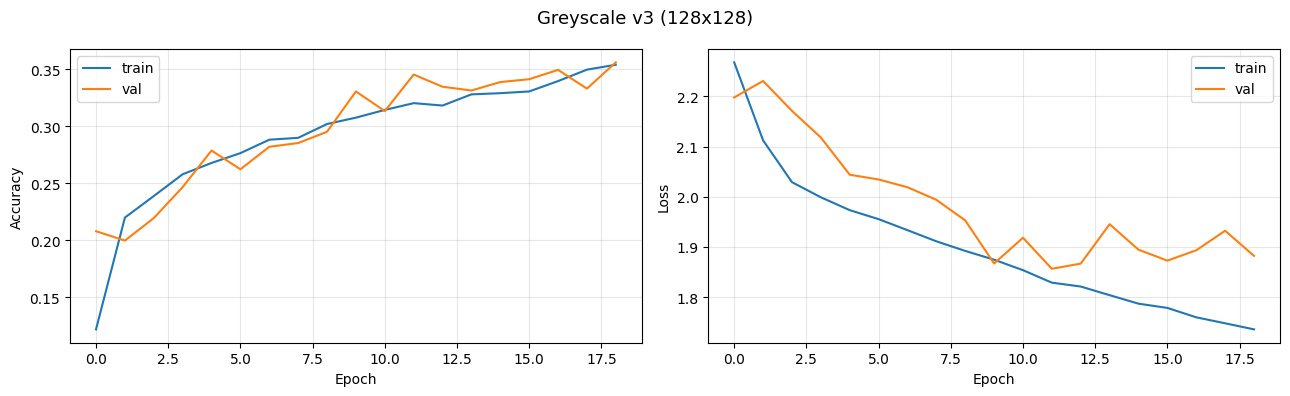

In [51]:
show_curves(hist_grey_v3, 'Greyscale v3 (128x128)')

In [52]:
y_true_gv3, y_pred_gv3, f1_grey_v3 = report_metrics(
    grey_v3, ds_val_grey, tag='Greyscale v3 (128) - Validation'
)


=== Greyscale v3 (128) - Validation ===
Accuracy :  0.3454
Macro F1 :  0.2989
Parameters: 128,266

              precision    recall  f1-score   support

     battery       0.46      0.67      0.55        67
  biological       0.28      0.47      0.35        76
   cardboard       0.45      0.29      0.35       139
     clothes       0.41      0.73      0.52       204
       glass       0.52      0.09      0.15       170
       metal       0.16      0.22      0.19        87
       paper       0.30      0.62      0.41       130
     plastic       0.41      0.11      0.17       171
       shoes       0.28      0.04      0.07       129
       trash       0.20      0.28      0.24        43

    accuracy                           0.35      1216
   macro avg       0.35      0.35      0.30      1216
weighted avg       0.37      0.35      0.30      1216



### 9.5 RGB vs Greyscale (Fair Comparison)

In [53]:
print(f'{"":<20} {"Macro F1":>10} {"Params":>12}')
print('-' * 44)
print(f'{"RGB v3":<20} {f1_v3:>10.4f} {rgb_v3.count_params():>12,}')
print(f'{"Greyscale v3":<20} {f1_grey_v3:>10.4f} {grey_v3.count_params():>12,}')
print()
diff = f1_v3 - f1_grey_v3
if diff > 0:
    print(f'RGB outperforms greyscale by {diff:.4f} macro F1.')
else:
    print(f'Greyscale outperforms RGB by {-diff:.4f} macro F1.')

                       Macro F1       Params
--------------------------------------------
RGB v3                   0.4513      128,842
Greyscale v3             0.2989      128,266

RGB outperforms greyscale by 0.1524 macro F1.


### 9.6 Observations on v3

The v3 model with wider filters (32, 64, 128) in three blocks did not beat the Deeper model, which uses narrower filters (16, 32, 64, 128) across four blocks. This suggests that for this dataset, having an extra level of spatial hierarchy matters more than simply using wider layers. The additional pooling step in the Deeper model forces the network to build up increasingly abstract representations, which helps it distinguish between 10 visually similar categories.

The Deeper model is the best scratch CNN so far. To satisfy the spec requirement of comparing RGB and greyscale with the same hyperparameters, the greyscale comparison below uses the Deeper architecture.

### 9.7 Greyscale with Best Scratch Architecture

Building a greyscale version of the Deeper model (4 blocks, 16-32-64-128) with the same hyperparameters for a fair comparison.

In [54]:
# Greyscale Deeper model - same architecture as best RGB scratch
aug_grey_deep = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

grey_deep = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 1)),
    aug_grey_deep,
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(n_classes)
])

grey_deep.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f'Greyscale Deeper params: {grey_deep.count_params():,}')

Greyscale Deeper params: 114,954


In [55]:
t0 = time.time()
hist_grey_deep = grey_deep.fit(
    ds_train_grey,
    validation_data=ds_val_grey,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
grey_deep_time = time.time() - t0
print(f'\nTraining time: {grey_deep_time:.1f}s ({grey_deep_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.0925 - loss: 2.2936 - val_accuracy: 0.1694 - val_loss: 2.2900
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.1860 - loss: 2.1634 - val_accuracy: 0.1743 - val_loss: 2.1962
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2229 - loss: 2.0832 - val_accuracy: 0.2064 - val_loss: 2.1184
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2202 - loss: 2.0461 - val_accuracy: 0.2229 - val_loss: 2.0832
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.2276 - loss: 2.0308 - val_accuracy: 0.2525 - val_loss: 2.0693
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2410 - loss: 2.0129 - val_accuracy: 0.2582 - val_loss: 2.0545
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2526 - loss: 1.9818 - val_accuracy: 0.2780 - val_loss: 2.0435
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.2637 - loss: 1.9571 - val_accu

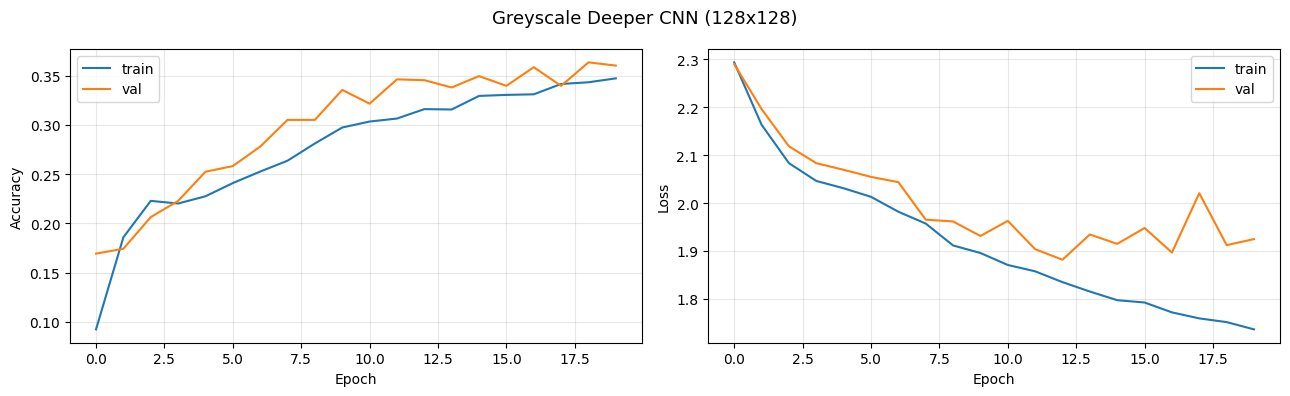

In [56]:
show_curves(hist_grey_deep, 'Greyscale Deeper CNN (128x128)')

In [57]:
y_true_gd, y_pred_gd, f1_grey_deep = report_metrics(
    grey_deep, ds_val_grey, tag='Greyscale Deeper (128) - Validation'
)


=== Greyscale Deeper (128) - Validation ===
Accuracy :  0.3454
Macro F1 :  0.2949
Parameters: 114,954

              precision    recall  f1-score   support

     battery       0.54      0.49      0.52        67
  biological       0.63      0.25      0.36        76
   cardboard       0.44      0.28      0.34       139
     clothes       0.38      0.81      0.51       204
       glass       0.57      0.07      0.13       170
       metal       0.15      0.22      0.18        87
       paper       0.27      0.67      0.39       130
     plastic       0.44      0.19      0.26       171
       shoes       0.50      0.01      0.02       129
       trash       0.23      0.28      0.25        43

    accuracy                           0.35      1216
   macro avg       0.41      0.33      0.29      1216
weighted avg       0.43      0.35      0.30      1216



### 9.8 RGB vs Greyscale (Matched Architecture)

In [58]:
print(f'{"":<24} {"Macro F1":>10} {"Params":>12}')
print('-' * 48)
print(f'{"RGB Deeper":<24} {f1_deep:>10.4f} {rgb_deep.count_params():>12,}')
print(f'{"Greyscale Deeper":<24} {f1_grey_deep:>10.4f} {grey_deep.count_params():>12,}')
print()
diff_colour = f1_deep - f1_grey_deep
print(f'RGB advantage: {diff_colour:.4f} macro F1')
print(f'Colour information clearly helps the model distinguish waste categories.')

                           Macro F1       Params
------------------------------------------------
RGB Deeper                   0.4531      115,242
Greyscale Deeper             0.2949      114,954

RGB advantage: 0.1582 macro F1
Colour information clearly helps the model distinguish waste categories.


---
## 10. Transfer Learning with VGG16

### 10.1 Approach

VGG16 was pre-trained on ImageNet (1.2 million images, 1000 classes) and has already learned powerful low-level and mid-level visual features like edges, textures and shapes. Instead of training from scratch, these learned features can be reused by freezing the VGG16 layers and only training a new classifier head on top.

VGG16 expects its inputs to be preprocessed using its own function (which centres the RGB channels around the ImageNet mean values), so `Rescaling(1./255)` is not used here.

There is no point trying greyscale with transfer learning since VGG16 was trained on RGB images and expects 3 input channels.

In [59]:
# Load VGG16 without the classification head
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_H, IMG_W, 3)
)

# Freeze all base layers so they are not updated during training
base_model.trainable = False

print(f'VGG16 base layers: {len(base_model.layers)}')
print(f'VGG16 base params: {base_model.count_params():,} (all frozen)')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
VGG16 base layers: 19
VGG16 base params: 14,714,688 (all frozen)


In [60]:
# Build full model using the Functional API
inputs = tf.keras.Input(shape=(IMG_H, IMG_W, 3))

# Augmentation (only active during training)
x = augmentation(inputs)

# VGG16's own preprocessing (centres RGB channels)
x = tf.keras.applications.vgg16.preprocess_input(x)

# Frozen feature extractor
x = base_model(x, training=False)

# Custom classifier head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(n_classes)(x)

vgg_model = tf.keras.Model(inputs, outputs)

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

vgg_model.summary(show_trainable=True)

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_14    │ (None, 128,     │         0 │ -              │   -   │
│ (InputLayer)      │ 128, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ sequential        │ (None, 128,     │         0 │ input_layer_1… │   -   │
│ (Sequential)      │ 128, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item          │ (None, 128,     │         0 │ sequential[4]… │   -   │
│ (GetItem)         │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_1        │ (None, 128,     │         0 │ sequential[4]… │   -   │
│ (GetItem)         │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_2        │ (None, 128,     │         0 │ sequential[4]… │   -   │
│ (GetItem)         │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stack (Stack)     │ (None, 128,     │         0 │ get_item[0][0… │   -   │
│                   │ 128, 3)         │           │ get_item_1[0]… │       │
│                   │                 │           │ get_item_2[0]… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ add (Add)         │ (None, 128,     │         0 │ stack[0][0]    │   -   │
│                   │ 128, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ vgg16             │ (None, 4, 4,    │ 14,714,6… │ add[0][0]      │   N   │
│ (Functional)      │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 512)     │         0 │ vgg16[0][0]    │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_16 (Dense)  │ (None, 256)     │   131,328 │ global_averag… │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_30        │ (None, 256)     │         0 │ dense_16[0][0] │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_17 (Dense)  │ (None, 10)      │     2,570 │ dropout_30[0]… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [61]:
# Train only the classifier head (base is frozen)
t0 = time.time()
hist_vgg_frozen = vgg_model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=30,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    )],
)
vgg_frozen_time = time.time() - t0
print(f'\nTraining time (frozen): {vgg_frozen_time:.1f}s ({vgg_frozen_time/60:.1f} min)')

Epoch 1/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - accuracy: 0.5553 - loss: 1.9545 - val_accuracy: 0.7673 - val_loss: 0.7747
Epoch 2/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.6903 - loss: 0.9577 - val_accuracy: 0.8010 - val_loss: 0.6443
Epoch 3/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.7235 - loss: 0.8399 - val_accuracy: 0.8059 - val_loss: 0.6291
Epoch 4/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.7426 - loss: 0.7644 - val_accuracy: 0.8224 - val_loss: 0.5836
Epoch 5/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.7553 - loss: 0.7067 - val_accuracy: 0.8331 - val_loss: 0.5614
Epoch 6/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.7764 - loss: 0.6458 - val_accuracy: 0.8446 - val_loss: 0.5331
Epoch 7/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.7841 - loss: 0.6146 - val_accuracy: 0.8462 - val_loss: 0.5230
Epoch 8/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.7904 - loss: 0.6114 - 

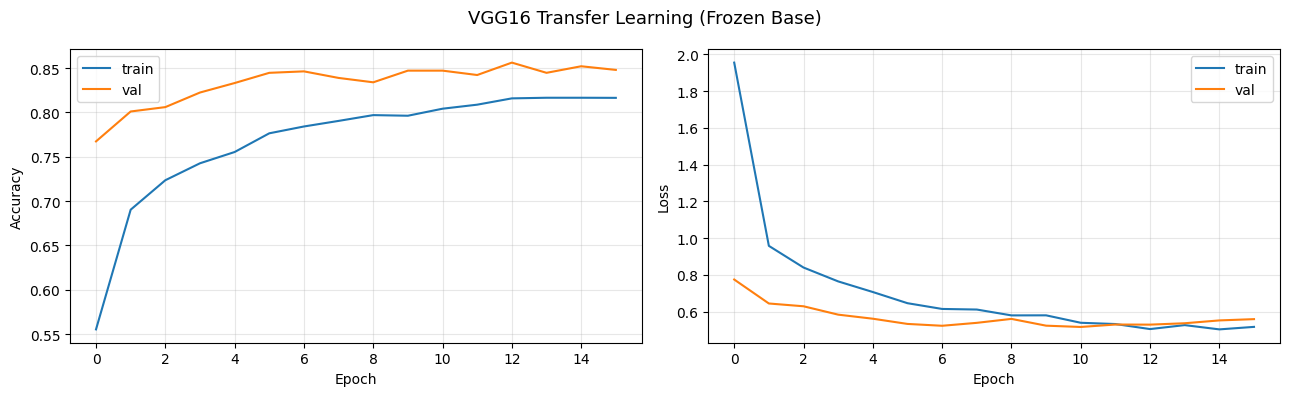

In [62]:
show_curves(hist_vgg_frozen, 'VGG16 Transfer Learning (Frozen Base)')

In [63]:
y_true_vf, y_pred_vf, f1_vgg_frozen = report_metrics(
    vgg_model, ds_val, tag='VGG16 Frozen Base - Validation'
)

# Record the validation loss before fine-tuning
val_loss_before = vgg_model.evaluate(ds_val, verbose=0)
print(f'\nValidation loss before fine-tuning: {val_loss_before[0]:.4f}')


=== VGG16 Frozen Base - Validation ===
Accuracy :  0.8470
Macro F1 :  0.8426
Parameters: 14,848,586

              precision    recall  f1-score   support

     battery       0.90      0.88      0.89        68
  biological       0.94      0.92      0.93        78
   cardboard       0.89      0.78      0.83       139
     clothes       0.98      0.96      0.97       198
       glass       0.88      0.80      0.84       163
       metal       0.59      0.80      0.68        95
       paper       0.73      0.86      0.79       135
     plastic       0.84      0.72      0.77       169
       shoes       0.90      0.97      0.93       126
       trash       0.87      0.73      0.80        45

    accuracy                           0.85      1216
   macro avg       0.85      0.84      0.84      1216
weighted avg       0.86      0.85      0.85      1216


Validation loss before fine-tuning: 0.5165


### 10.2 Fine-Tuning

The spec requires at least one epoch of fine-tuning: unfreezing the top layers of the base model and retraining with a very low learning rate. This lets the pre-trained features adapt slightly to our specific dataset.

Only the top convolutional block (block5) is unfrozen. The earlier layers contain low-level features (edges, textures) that generalise across tasks and should stay fixed. A learning rate of 1e-5 is used to avoid destroying the pre-trained weights with large updates.

In [64]:
# Unfreeze the top block of VGG16
base_model.trainable = True

# Keep all layers frozen except the last convolutional block (block5)
for layer in base_model.layers:
    if not layer.name.startswith('block5'):
        layer.trainable = False

# Count trainable vs frozen
trainable = sum(1 for l in base_model.layers if l.trainable)
frozen = sum(1 for l in base_model.layers if not l.trainable)
print(f'Base model layers: {trainable} trainable, {frozen} frozen')
print(f'Total trainable params: {sum(tf.keras.backend.count_params(w) for w in vgg_model.trainable_weights):,}')

Base model layers: 4 trainable, 15 frozen
Total trainable params: 7,213,322


In [65]:
# Recompile with a much lower learning rate
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Fine-tune for a few epochs
t0 = time.time()
hist_vgg_ft = vgg_model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=5,
    class_weight=class_weights,
)
vgg_ft_time = time.time() - t0
print(f'\nFine-tuning time: {vgg_ft_time:.1f}s ({vgg_ft_time/60:.1f} min)')

Epoch 1/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.8303 - loss: 0.4742 - val_accuracy: 0.8520 - val_loss: 0.5207
Epoch 2/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 68ms/step - accuracy: 0.8467 - loss: 0.4444 - val_accuracy: 0.8660 - val_loss: 0.4997
Epoch 3/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - accuracy: 0.8556 - loss: 0.4047 - val_accuracy: 0.8660 - val_loss: 0.5024
Epoch 4/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.8704 - loss: 0.3647 - val_accuracy: 0.8651 - val_loss: 0.5231
Epoch 5/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.8797 - loss: 0.3424 - val_accuracy: 0.8750 - val_loss: 0.4957

Fine-tuning time: 92.4s (1.5 min)


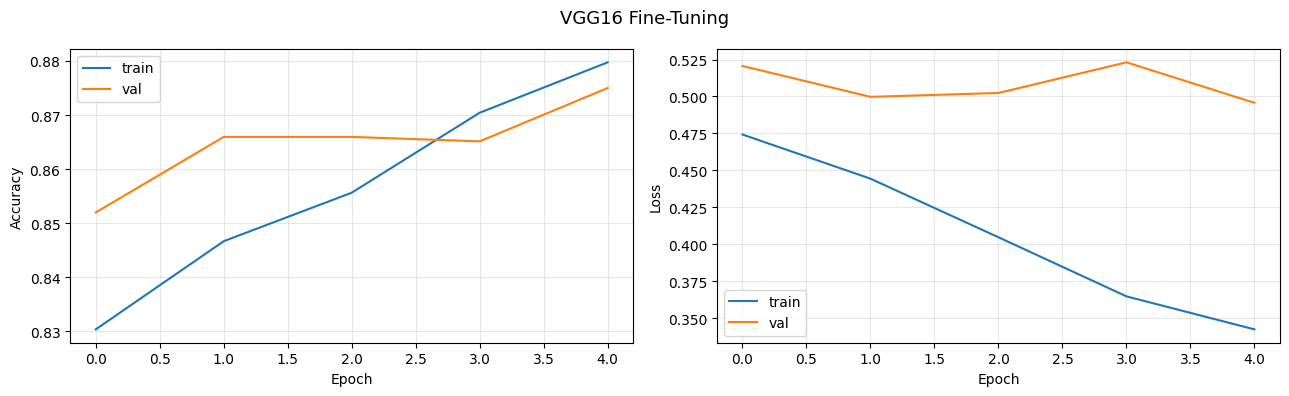

In [66]:
show_curves(hist_vgg_ft, 'VGG16 Fine-Tuning')

In [67]:
# Compare validation loss before and after fine-tuning
val_loss_after = vgg_model.evaluate(ds_val, verbose=0)
print(f'Validation loss BEFORE fine-tuning: {val_loss_before[0]:.4f}')
print(f'Validation loss AFTER  fine-tuning: {val_loss_after[0]:.4f}')
print()
if val_loss_after[0] < val_loss_before[0]:
    print(f'Fine-tuning reduced validation loss by {val_loss_before[0] - val_loss_after[0]:.4f}.')
else:
    print(f'Fine-tuning did not improve validation loss (increased by {val_loss_after[0] - val_loss_before[0]:.4f}).')

Validation loss BEFORE fine-tuning: 0.5165
Validation loss AFTER  fine-tuning: 0.4957

Fine-tuning reduced validation loss by 0.0208.


In [68]:
y_true_vft, y_pred_vft, f1_vgg_ft = report_metrics(
    vgg_model, ds_val, tag='VGG16 After Fine-Tuning - Validation'
)


=== VGG16 After Fine-Tuning - Validation ===
Accuracy :  0.8750
Macro F1 :  0.8686
Parameters: 14,848,586

              precision    recall  f1-score   support

     battery       0.89      0.97      0.93        68
  biological       0.96      0.92      0.94        78
   cardboard       0.93      0.88      0.91       139
     clothes       0.98      0.96      0.97       198
       glass       0.86      0.87      0.86       163
       metal       0.68      0.75      0.71        95
       paper       0.82      0.84      0.83       135
     plastic       0.88      0.75      0.81       169
       shoes       0.85      1.00      0.92       126
       trash       0.87      0.76      0.81        45

    accuracy                           0.88      1216
   macro avg       0.87      0.87      0.87      1216
weighted avg       0.88      0.88      0.87      1216



---
## 11. Overall Model Comparison

All models compared on the **validation set** using macro F1 as the primary metric. The test set has not been touched yet.

In [69]:
# Collect all results
comparison = [
    ('Baseline (128)',          f1_baseline, rgb_baseline.count_params(), baseline_time),
    ('v2 Dropout (128)',        f1_v2,       rgb_v2.count_params(),       v2_time),
    ('Deeper (128)',            f1_deep,     rgb_deep.count_params(),     deep_time),
    ('Small (64)',              f1_small,    rgb_small.count_params(),    small_time),
    ('v3 Larger (128)',         f1_v3,       rgb_v3.count_params(),       v3_time),
    ('Greyscale Deeper (128)',  f1_grey_deep,grey_deep.count_params(),   grey_deep_time),
    ('VGG16 Frozen',           f1_vgg_frozen,vgg_model.count_params(),   vgg_frozen_time),
    ('VGG16 Fine-Tuned',       f1_vgg_ft,   vgg_model.count_params(),   vgg_frozen_time + vgg_ft_time),
]

# Sort by F1
comparison.sort(key=lambda x: x[1], reverse=True)

print(f'{"Model":<26} {"Macro F1":>10} {"Params":>14} {"Time (s)":>10}')
print('=' * 64)
for name, f1, params, t in comparison:
    best = ' *' if f1 == comparison[0][1] else ''
    print(f'{name:<26} {f1:>10.4f} {params:>14,} {t:>10.1f}{best}')
print()
print(f'* = best validation macro F1')

Model                        Macro F1         Params   Time (s)
VGG16 Fine-Tuned               0.8686     14,848,586      329.4 *
VGG16 Frozen                   0.8426     14,848,586      237.0
Deeper (128)                   0.4531        115,242      169.7
v3 Larger (128)                0.4513        128,842      215.8
Baseline (128)                 0.4481         33,194      126.3
v2 Dropout (128)               0.4155         33,194      230.6
Small (64)                     0.3621         33,194      112.9
Greyscale Deeper (128)         0.2949        114,954       95.6

* = best validation macro F1


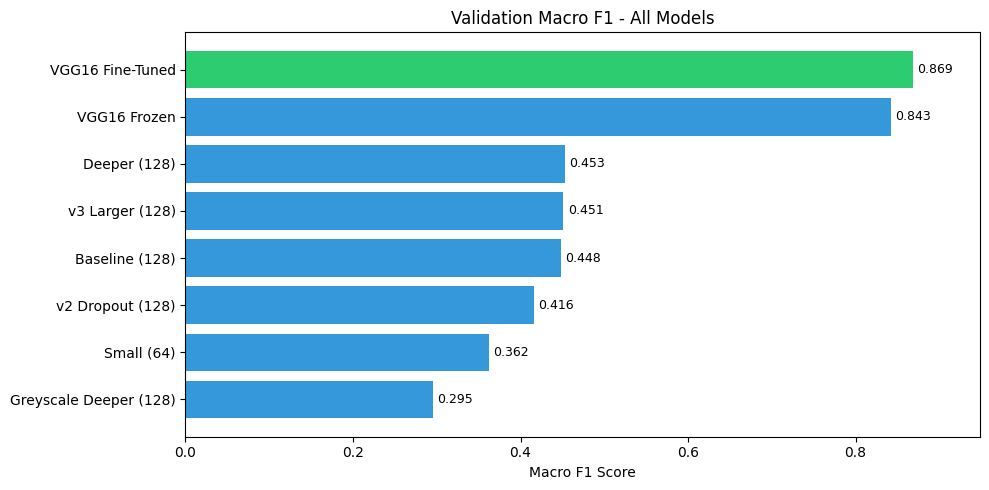

In [70]:
# Visual comparison
model_names = [c[0] for c in comparison]
f1_scores = [c[1] for c in comparison]

fig, ax = plt.subplots(figsize=(10, 5))
colours = ['#2ecc71' if s == max(f1_scores) else '#3498db' for s in f1_scores]
bars = ax.barh(model_names, f1_scores, color=colours)

for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=9)

ax.set_xlabel('Macro F1 Score')
ax.set_title('Validation Macro F1 - All Models')
ax.set_xlim(0, max(f1_scores) + 0.08)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 11.1 Select Best Model

The model with the highest validation macro F1 is selected as the final model. It will be evaluated **once** on the held-out test set in the next section.

In [71]:
# Identify the best model
best_name = comparison[0][0]
best_f1 = comparison[0][1]
print(f'Best model: {best_name} (validation macro F1 = {best_f1:.4f})')
print()

# Determine which model object to use for final test evaluation
if 'VGG16' in best_name:
    final_model = vgg_model
    final_ds_test = ds_test
elif 'Deeper' in best_name and 'Grey' not in best_name:
    final_model = rgb_deep
    final_ds_test = ds_test
elif 'Grey' in best_name:
    final_model = grey_deep
    final_ds_test = ds_test_grey
else:
    # Fallback
    final_model = rgb_deep
    final_ds_test = ds_test
    print('Note: defaulting to Deeper model for test evaluation.')

print(f'This model will now be evaluated on the test set.')

Best model: VGG16 Fine-Tuned (validation macro F1 = 0.8686)

This model will now be evaluated on the test set.


---
## 12. Final Test Set Evaluation

The test set is used exactly once to report the final performance of the chosen model. This result is what goes into the paper.

In [72]:
y_true_final, y_pred_final, f1_final = report_metrics(
    final_model, final_ds_test, tag=f'FINAL TEST - {best_name}'
)


=== FINAL TEST - VGG16 Fine-Tuned ===
Accuracy :  0.8736
Macro F1 :  0.8649
Parameters: 14,848,586

              precision    recall  f1-score   support

     battery       0.90      0.95      0.92       140
  biological       0.92      0.91      0.92       117
   cardboard       0.89      0.84      0.86       277
     clothes       0.98      0.97      0.97       387
       glass       0.86      0.84      0.85       321
       metal       0.73      0.85      0.78       204
       paper       0.87      0.85      0.86       310
     plastic       0.85      0.75      0.80       318
       shoes       0.90      0.97      0.93       287
       trash       0.74      0.74      0.74       100

    accuracy                           0.87      2461
   macro avg       0.86      0.87      0.86      2461
weighted avg       0.88      0.87      0.87      2461



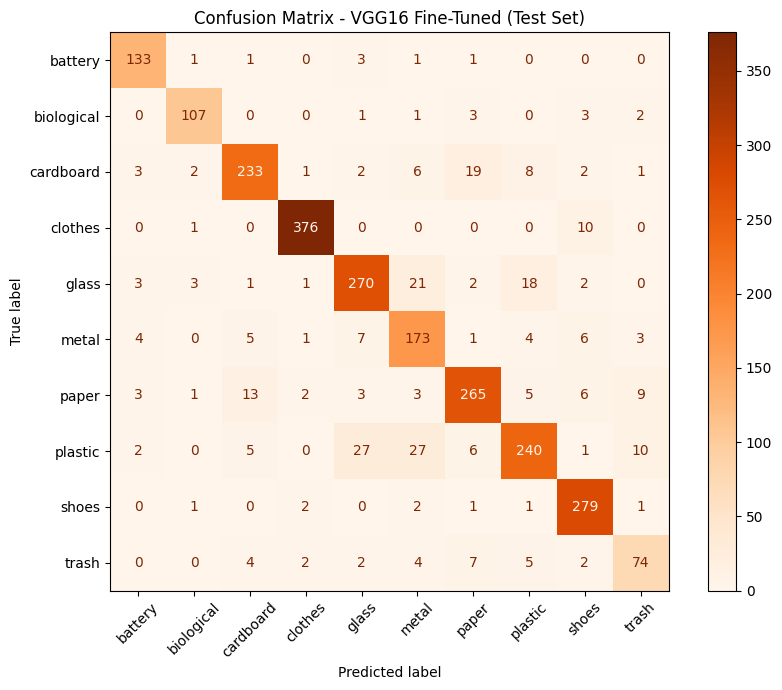

In [73]:
show_confusion(y_true_final, y_pred_final,
               title=f'Confusion Matrix - {best_name} (Test Set)')

In [74]:
# Inference time on the test set
inf_time = measure_inference(final_model, final_ds_test, n_runs=10)

Mean inference time (1 batch, 10 runs): 0.0994 s


---
## 13. Real-World Test

Four photographs of household waste items were taken with a handwritten note showing the student name and ID (G00425385) visible in each image. These are tested against the final model to see how it handles images from outside the training distribution.

The photos are stored on Google Drive and loaded below.

In [75]:
# ---- Path to your photos folder on Drive ----
PHOTO_DIR = '/content/drive/MyDrive/garbage_4/resized'  # <- update if needed

# What category each photo actually is (in the same order as the filenames)
# UPDATE these to match your actual photos
true_labels = ['battery', 'cardboard', 'clothes', 'shoes']

# List the photos
photo_files = sorted([
    f for f in os.listdir(PHOTO_DIR)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

print(f'Found {len(photo_files)} photos:')
for f in photo_files:
    print(f'  {f}')

if len(photo_files) != 4:
    print(f'\nWARNING: Expected 4 photos, found {len(photo_files)}.')
    print('Check PHOTO_DIR path and make sure only your 4 test photos are in there.')

Found 4 photos:
  battery_1.jpg
  cardboard_2.jpg
  clothes_3.jpg
  shoes_4.jpg


In [76]:
# Load, resize and predict
photos = []
photo_arrays = []

for fname in photo_files:
    path = os.path.join(PHOTO_DIR, fname)
    img = tf.keras.utils.load_img(path, target_size=(IMG_H, IMG_W))
    photos.append(img)
    photo_arrays.append(tf.keras.utils.img_to_array(img))

# Stack into a batch
photo_batch = np.array(photo_arrays)
print(f'Photo batch shape: {photo_batch.shape}')
print(f'Pixel range: [{photo_batch.min():.0f}, {photo_batch.max():.0f}]')

Photo batch shape: (4, 128, 128, 3)
Pixel range: [0, 255]


In [77]:
# Run predictions
logits = final_model.predict(photo_batch)
predicted_indices = np.argmax(logits, axis=1)
predicted_labels = [label_names[i] for i in predicted_indices]

# Confidence scores (softmax over logits)
probs = tf.nn.softmax(logits).numpy()
confidences = [probs[i, predicted_indices[i]] for i in range(len(photo_files))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step


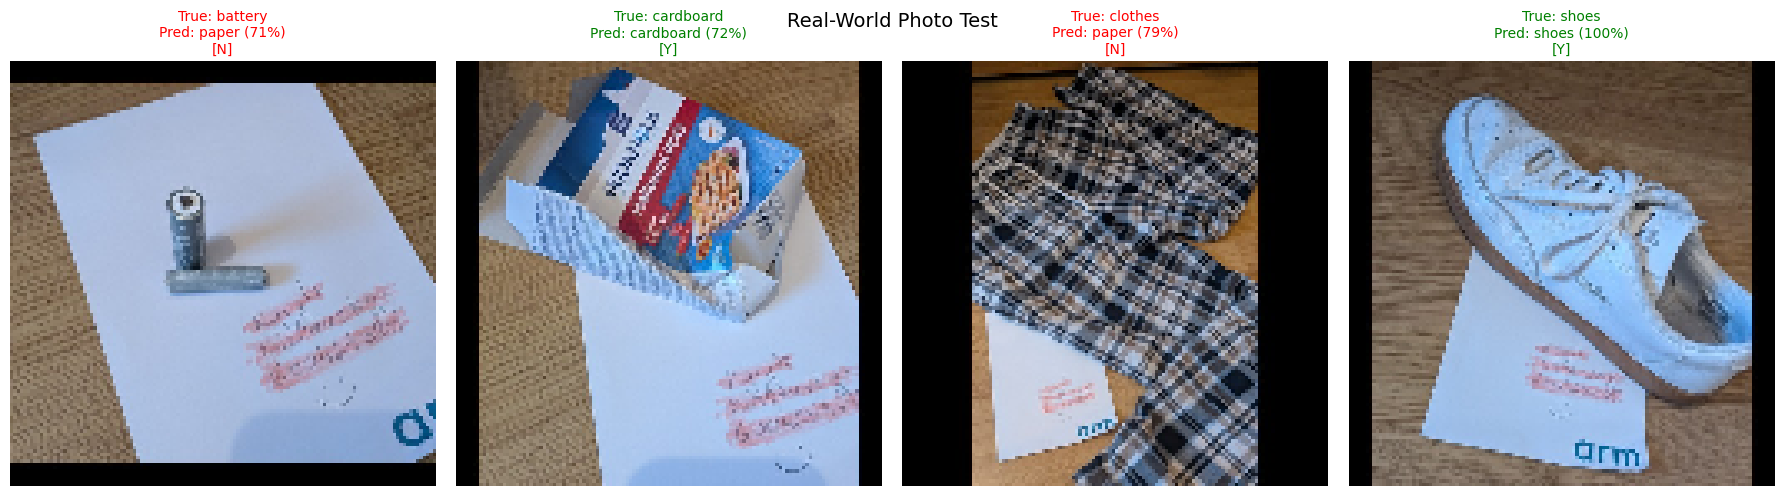

In [78]:
# Display photos with predictions
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, ax in enumerate(axes):
    ax.imshow(photos[i])
    ax.axis('off')

    actual = true_labels[i]
    pred = predicted_labels[i]
    conf = confidences[i]
    correct = actual == pred

    colour = 'green' if correct else 'red'
    symbol = 'Y' if correct else 'N'
    ax.set_title(
        f'True: {actual}\n'
        f'Pred: {pred} ({conf:.0%})\n'
        f'[{symbol}]',
        fontsize=10, color=colour
    )

fig.suptitle('Real-World Photo Test', fontsize=14)
plt.tight_layout()
plt.show()

In [79]:
# Summary
n_correct = sum(1 for a, p in zip(true_labels, predicted_labels) if a == p)

print(f'{"Photo":<30} {"Actual":<14} {"Predicted":<14} {"Conf":>6} {"":>6}')
print('-' * 74)
for i, fname in enumerate(photo_files):
    actual = true_labels[i]
    pred = predicted_labels[i]
    conf = confidences[i]
    match = 'OK' if actual == pred else 'WRONG'
    print(f'{fname:<30} {actual:<14} {pred:<14} {conf:>5.1%} {match:>6}')

print('-' * 74)
print(f'Result: {n_correct}/4 correct')

Photo                          Actual         Predicted        Conf       
--------------------------------------------------------------------------
battery_1.jpg                  battery        paper          70.7%  WRONG
cardboard_2.jpg                cardboard      cardboard      71.9%     OK
clothes_3.jpg                  clothes        paper          79.2%  WRONG
shoes_4.jpg                    shoes          shoes          100.0%     OK
--------------------------------------------------------------------------
Result: 2/4 correct


In [80]:
# Show top-3 predictions for each photo
print('Top-3 predictions per photo:\n')
for i, fname in enumerate(photo_files):
    print(f'{fname}  (actual: {true_labels[i]})')
    top3 = np.argsort(probs[i])[::-1][:3]
    for rank, idx in enumerate(top3, 1):
        marker = ' <--' if label_names[idx] == true_labels[i] else ''
        print(f'  {rank}. {label_names[idx]:<14} {probs[i, idx]:>6.1%}{marker}')
    print()

Top-3 predictions per photo:

battery_1.jpg  (actual: battery)
  1. paper           70.7%
  2. cardboard       28.9%
  3. plastic          0.4%

cardboard_2.jpg  (actual: cardboard)
  1. cardboard       71.9% <--
  2. paper           28.0%
  3. plastic          0.0%

clothes_3.jpg  (actual: clothes)
  1. paper           79.2%
  2. cardboard       10.5%
  3. clothes          9.4% <--

shoes_4.jpg  (actual: shoes)
  1. shoes          100.0% <--
  2. clothes          0.0%
  3. paper            0.0%



---

**All phases complete.** The notebook is ready for submission.